# Modelo Fundacional de Google: TimesFM 2.5 en FatigueSet

Este notebook integra y evalúa el modelo fundacional **Google TimesFM 2.5 (200M)** en el experimento comparativo de predicción de fatiga:

| Modelo | Tipo | Paradigma | Parámetros | Estrategia |
|---|---|---|---|---|
| **TimesFM 2.5** (Das et al., 2024) | Decoder-only (parches) | Preentrenado (PyTorch) | 200M | Zero-shot + Linear probe |

### TimesFM e In-Context Learning / Zero-Shot
TimesFM es un modelo decoder-only preentrenado por Google Research para pronósticos de series temporales. Acepta parches de entrada de forma continua y genera predicciones puntuales y de cuantiles para el futuro de la serie.

En este experimento, adaptamos TimesFM a FatigueSet mediante **independencia de canales (channel independence)**:
1. Cada canal fisiológico de la ventana se pasa a TimesFM para predecir el siguiente paso.
2. Las predicciones del paso siguiente de los 23 canales se usan como características (features) para entrenar una **sonda lineal (Ridge Regression)**.
3. Evaluamos tanto la precisión determinista como la calibración probabilística a través del **CRPS** e **intervalos de cobertura al 90%**.

---
### Configuración: Local vs. Servidor
Cambia `SERVER_MODE = True` al ejecutar en el servidor de cómputo potente para usar los parámetros definitivos de la tesis.

## 0. Configuración Global: Local vs. Servidor

In [1]:
# =====================================================================
# CONFIGURA AQUÍ: False = pruebas locales | True = servidor potente
# =====================================================================
SERVER_MODE = False

# Parámetros que cambian según el entorno
if SERVER_MODE:
    EPOCHS         = 30
    N_SPLITS       = 5
    BATCH_SIZE     = 32
    SEQ_LEN        = 512
    STEP           = 128
    PER_CORE_BATCH = 128
else:
    EPOCHS         = 5     # Sanity check local
    N_SPLITS       = 3
    BATCH_SIZE     = 8
    SEQ_LEN        = 128
    STEP           = 64
    PER_CORE_BATCH = 32    # Batch size para GPU local

SEED   = 42
CHECKPOINT = "google/timesfm-2.5-200m-pytorch"

print(f"Modo: {'SERVIDOR' if SERVER_MODE else 'LOCAL (pruebas)'}")
print(f"TimesFM checkpoint: {CHECKPOINT}")
print(f"Batch size GPU: {PER_CORE_BATCH}")

Modo: LOCAL (pruebas)
TimesFM checkpoint: google/timesfm-2.5-200m-pytorch
Batch size GPU: 32


## 1. Importaciones

In [2]:
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

import torch
import torch.nn as nn

# Añadir fatigueset-lib al path
lib_path = str(Path.cwd().parent / "fatigueset-lib")
if lib_path not in sys.path:
    sys.path.insert(0, lib_path)

from fatigueset import FatigueSetPipeline
from fatigueset.models.rnn import _prepare_target_table, _merge_raw_streams, _build_sequences
from fatigueset.models import (
    TimesFMZeroShotEvaluator,
    compute_crps_gaussian,
    compute_coverage,
    evaluate_probabilistic_metrics,
)

torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")
print(f"PyTorch: {torch.__version__}")

Dispositivo: cuda
PyTorch: 2.6.0+cu124


## 2. Instalación y Verificación de Dependencias

In [3]:
try:
    import timesfm
    print("✅ timesfm instalado correctamente")
except ImportError:
    print("❌ timesfm no instalado. Instálalo con: pip install timesfm")

✅ timesfm instalado correctamente


## 3. Carga del Dataset FatigueSet

In [4]:
dataset_path = str(Path.cwd().parent / "fatigueset")
pipeline = FatigueSetPipeline(dataset_path=dataset_path, umbral_nulos=5.0)

print("Cargando dataset...")
raw = pipeline.cargar_dataset(verbose=False)
df_ml = pipeline.construir_dataset_ml(raw)
df_targets = _prepare_target_table(df_ml)
df_raw = _merge_raw_streams(raw)

print(f"Construyendo secuencias (seq_len={SEQ_LEN}, step={STEP})...")
X_arr, y_arr, groups, feature_cols = _build_sequences(
    df_raw=df_raw,
    df_targets=df_targets,
    seq_len=SEQ_LEN,
    step=STEP,
)

N_FEATURES = len(feature_cols)

print(f"\n[OK] Dataset listo:")
print(f"  X: {X_arr.shape} | y: {y_arr.shape} | Grupos: {len(np.unique(groups))}")
print(f"  Features ({N_FEATURES}): {feature_cols[:5]}...")

Cargando dataset...


Construyendo secuencias (seq_len=128, step=64)...

[OK] Dataset listo:
  X: (660, 128, 23) | y: (660, 2) | Grupos: 12
  Features (23): ['chest_hr', 'chest_br', 'chest_posture', 'chest_hr_confidence', 'chest_hrv']...


## 4. TimesFM: Inferencia Zero-Shot y Extracción de Características

### Sanity Check de Inferencia
Instanciamos y compilamos el evaluador para verificar que carga y predice correctamente con un batch pequeño de FatigueSet.

In [5]:
print("=" * 60)
print("SANITY CHECK: TimesFM 2.5 PyTorch")
print("=" * 60)

try:
    evaluator = TimesFMZeroShotEvaluator(
        checkpoint=CHECKPOINT,
        prediction_length=1,
        max_context=SEQ_LEN,
        per_core_batch_size=PER_CORE_BATCH,
        device=device,
    )
    evaluator._load_model()

    # Extraer características para 2 muestras de prueba
    test_feats, test_quantiles = evaluator.extract_features(X_arr[:2], batch_size=2)

    print(f"\n[OK] Features extraídas:  {test_feats.shape} (esperado: [2, {N_FEATURES}])")
    print(f"[OK] Quantiles extraídos: {test_quantiles.shape} (esperado: [2, {N_FEATURES}, 10])")
    TIMESFM_AVAILABLE = True

except Exception as e:
    import traceback
    print(f"[ERROR] Error al inicializar TimesFM: {e}")
    traceback.print_exc()
    TIMESFM_AVAILABLE = False

SANITY CHECK: TimesFM 2.5 PyTorch
[TimesFM] Cargando modelo desde 'google/timesfm-2.5-200m-pytorch'...


[TimesFM] Modelo y config listos en 4.7s



[OK] Features extraídas:  (2, 23) (esperado: [2, 23])
[OK] Quantiles extraídos: (2, 23, 10) (esperado: [2, 23, 10])


## 5. Evaluación de TimesFM con GroupKFold por Participante

Llevamos a cabo una validación cruzada por participante. En cada fold:
1. Extraemos características de train y test usando TimesFM (23 medianas de predicción de canales).
2. Ajustamos una sonda de regresión Ridge en train.
3. Generamos predicciones deterministas en test para fatiga física y mental.

In [6]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TIMESFM_RESULTS = []
TIMESFM_TIME = None

if TIMESFM_AVAILABLE:
    print("\n" + "=" * 60)
    print("TimesFM: Zero-shot + Linear Probe con GroupKFold")
    print("=" * 60)
    print(f"  Folds:       {N_SPLITS}")
    print(f"  Batch size:  {BATCH_SIZE}")

    kf = GroupKFold(n_splits=N_SPLITS)
    t_start = time.time()

    for fold_idx, (train_idx, val_idx) in enumerate(
        kf.split(np.arange(len(X_arr)), groups=groups), start=1
    ):
        print(f"\n[TimesFM] Fold {fold_idx}/{N_SPLITS} — train: {len(train_idx)}, val: {len(val_idx)}")

        X_train = X_arr[train_idx]
        y_train = y_arr[train_idx]
        X_val   = X_arr[val_idx]
        y_val   = y_arr[val_idx]

        # Inferencia y entrenamiento de sonda
        y_pred, feats_val, probe = evaluator.fit_probe(X_train, y_train, X_val)

        fold_metrics = {
            "fold": fold_idx,
            "mae_fisica":  float(mean_absolute_error(y_val[:, 0], y_pred[:, 0])),
            "rmse_fisica": float(np.sqrt(mean_squared_error(y_val[:, 0], y_pred[:, 0]))),
            "r2_fisica":   float(r2_score(y_val[:, 0], y_pred[:, 0])),
            "mae_mental":  float(mean_absolute_error(y_val[:, 1], y_pred[:, 1])),
            "rmse_mental": float(np.sqrt(mean_squared_error(y_val[:, 1], y_pred[:, 1]))),
            "r2_mental":   float(r2_score(y_val[:, 1], y_pred[:, 1])),
            "n_val": len(val_idx),
        }
        TIMESFM_RESULTS.append(fold_metrics)
        print(
            f"  MAE física: {fold_metrics['mae_fisica']:.4f} | "
            f"R² física: {fold_metrics['r2_fisica']:.4f} | "
            f"MAE mental: {fold_metrics['mae_mental']:.4f} | "
            f"R² mental: {fold_metrics['r2_mental']:.4f}"
        )

    TIMESFM_TIME = time.time() - t_start

    df_timesfm = pd.DataFrame(TIMESFM_RESULTS)
    print("\n=== TimesFM: Estadísticas Globales ===")
    for col in [c for c in df_timesfm.columns if c not in ('fold', 'n_val')]:
        vals = df_timesfm[col].values
        print(f"  {col:30s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
    print(f"\nTiempo total evaluación: {TIMESFM_TIME:.1f}s")
else:
    print("[SKIP] TimesFM no disponible en local.")


TimesFM: Zero-shot + Linear Probe con GroupKFold
  Folds:       3
  Batch size:  8

[TimesFM] Fold 1/3 — train: 439, val: 221
[TimesFM] Extrayendo características del conjunto de entrenamiento...


[TimesFM] Extrayendo características del conjunto de validación...


  MAE física: 9.6145 | R² física: -0.2357 | MAE mental: 10.9667 | R² mental: -1.2822

[TimesFM] Fold 2/3 — train: 440, val: 220
[TimesFM] Extrayendo características del conjunto de entrenamiento...


[TimesFM] Extrayendo características del conjunto de validación...


  MAE física: 20.7136 | R² física: -1.9176 | MAE mental: 26.8364 | R² mental: -0.7801

[TimesFM] Fold 3/3 — train: 441, val: 219
[TimesFM] Extrayendo características del conjunto de entrenamiento...


[TimesFM] Extrayendo características del conjunto de validación...


  MAE física: 18.8380 | R² física: -1.1513 | MAE mental: 29.3335 | R² mental: -2.2274

=== TimesFM: Estadísticas Globales ===
  mae_fisica                    : 16.3887 ± 4.8509
  rmse_fisica                   : 20.1453 ± 5.5309
  r2_fisica                     : -1.1015 ± 0.6875
  mae_mental                    : 22.3788 ± 8.1338
  rmse_mental                   : 26.7108 ± 9.2359
  r2_mental                     : -1.4299 ± 0.6000

Tiempo total evaluación: 536.7s


## 6. Métricas Probabilísticas de TimesFM (CRPS + Cobertura)

Usando los residuos empíricos de entrenamiento como varianza de la predicción, estimamos el **CRPS** de validación bajo supuesto gaussiano y medimos la cobertura real de intervalos de confianza al 90% (±1.645 desv. estándar).

In [7]:
PROB_METRICS = {}

if TIMESFM_AVAILABLE:
    print("\n" + "=" * 60)
    print("TimesFM: Métricas Probabilísticas (CRPS + Cobertura)")
    print("=" * 60)

    kf = GroupKFold(n_splits=N_SPLITS)
    crps_fisica_list, crps_mental_list = [], []
    cov_fisica_list, cov_mental_list = [], []

    for fold_idx, (train_idx, val_idx) in enumerate(
        kf.split(np.arange(len(X_arr)), groups=groups), start=1
    ):
        X_train = X_arr[train_idx]
        y_train = y_arr[train_idx]
        X_val  = X_arr[val_idx]
        y_val  = y_arr[val_idx]

        # Ajustar sonda y predecir
        y_pred_val, feats_val, probe = evaluator.fit_probe(X_train, y_train, X_val)

        # Estimar sigma a partir de residuos en train
        feats_train, _ = evaluator.extract_features(X_train)
        y_pred_train = probe.predict(feats_train)
        residuals_train = y_train - y_pred_train
        sigma_fisica = np.std(residuals_train[:, 0]) + 1e-8
        sigma_mental = np.std(residuals_train[:, 1]) + 1e-8

        # Calcular CRPS
        crps_f = compute_crps_gaussian(y_val[:, 0], y_pred_val[:, 0], np.full(len(y_val), sigma_fisica))
        crps_m = compute_crps_gaussian(y_val[:, 1], y_pred_val[:, 1], np.full(len(y_val), sigma_mental))

        # Calcular Cobertura 90%
        z90 = 1.645
        cov_f = compute_coverage(y_val[:, 0], y_pred_val[:, 0] - z90 * sigma_fisica, y_pred_val[:, 0] + z90 * sigma_fisica)
        cov_m = compute_coverage(y_val[:, 1], y_pred_val[:, 1] - z90 * sigma_mental, y_pred_val[:, 1] + z90 * sigma_mental)

        crps_fisica_list.append(crps_f)
        crps_mental_list.append(crps_m)
        cov_fisica_list.append(cov_f)
        cov_mental_list.append(cov_m)

        print(f"[TimesFM Fold {fold_idx}] CRPS física: {crps_f:.4f} | Cov. 90% física: {cov_f:.1%}")
        print(f"                     CRPS mental: {crps_m:.4f} | Cov. 90% mental: {cov_m:.1%}")

    PROB_METRICS = {
        "crps_fisica_mean":  float(np.mean(crps_fisica_list)),
        "crps_fisica_std":   float(np.std(crps_fisica_list)),
        "crps_mental_mean":  float(np.mean(crps_mental_list)),
        "crps_mental_std":   float(np.std(crps_mental_list)),
        "coverage90_fisica": float(np.mean(cov_fisica_list)),
        "coverage90_mental": float(np.mean(cov_mental_list)),
    }

    print("\n=== TimesFM: Resumen Métricas Probabilísticas ===")
    print(f"  CRPS físico:  {PROB_METRICS['crps_fisica_mean']:.4f} ± {PROB_METRICS['crps_fisica_std']:.4f}")
    print(f"  CRPS mental:  {PROB_METRICS['crps_mental_mean']:.4f} ± {PROB_METRICS['crps_mental_std']:.4f}")
    print(f"  Cobertura 90% física: {PROB_METRICS['coverage90_fisica']:.1%}")
    print(f"  Cobertura 90% mental: {PROB_METRICS['coverage90_mental']:.1%}")
else:
    print("[SKIP] TimesFM no disponible.")


TimesFM: Métricas Probabilísticas (CRPS + Cobertura)
[TimesFM] Extrayendo características del conjunto de entrenamiento...


[TimesFM] Extrayendo características del conjunto de validación...


[TimesFM Fold 1] CRPS física: 7.1946 | Cov. 90% física: 95.0%
                     CRPS mental: 8.4869 | Cov. 90% mental: 99.5%
[TimesFM] Extrayendo características del conjunto de entrenamiento...


[TimesFM] Extrayendo características del conjunto de validación...


[TimesFM Fold 2] CRPS física: 16.5436 | Cov. 90% física: 50.9%
                     CRPS mental: 20.2158 | Cov. 90% mental: 45.9%
[TimesFM] Extrayendo características del conjunto de entrenamiento...


[TimesFM] Extrayendo características del conjunto de validación...


[TimesFM Fold 3] CRPS física: 13.8480 | Cov. 90% física: 60.3%
                     CRPS mental: 23.1894 | Cov. 90% mental: 42.9%

=== TimesFM: Resumen Métricas Probabilísticas ===
  CRPS físico:  12.5287 ± 3.9291
  CRPS mental:  17.2974 ± 6.3471
  Cobertura 90% física: 68.7%
  Cobertura 90% mental: 62.8%


## 7. Persistencia de Resultados

In [8]:
output_dir = Path.cwd().parent / "output"
output_dir.mkdir(exist_ok=True)

rows = []
if TIMESFM_RESULTS:
    rows.append({
        "Modelo": "TimesFM 2.5 (200M)",
        "Tipo": "Foundation (decoder-only parches)",
        "Paradigma": "Zero-shot + Linear probe",
        "Probabilístico": "Sí",
        "MAE Física": np.mean([r['mae_fisica'] for r in TIMESFM_RESULTS]),
        "RMSE Física": np.mean([r['rmse_fisica'] for r in TIMESFM_RESULTS]),
        "R² Física": np.mean([r['r2_fisica'] for r in TIMESFM_RESULTS]),
        "MAE Mental": np.mean([r['mae_mental'] for r in TIMESFM_RESULTS]),
        "RMSE Mental": np.mean([r['rmse_mental'] for r in TIMESFM_RESULTS]),
        "R² Mental": np.mean([r['r2_mental'] for r in TIMESFM_RESULTS]),
        "CRPS Física": PROB_METRICS.get('crps_fisica_mean', float('nan')),
        "CRPS Mental": PROB_METRICS.get('crps_mental_mean', float('nan')),
        "Cobertura 90%": PROB_METRICS.get('coverage90_fisica', float('nan')),
        "Nº Params (entrenables)": 0,
        "Tiempo (s)": TIMESFM_TIME,
    })

df_timesfm_comp = pd.DataFrame(rows)
if not df_timesfm_comp.empty:
    df_timesfm_comp.to_csv(output_dir / "resultados_timesfm.csv", index=False)
    print(f"[OK] Resultados guardados en: {output_dir / 'resultados_timesfm.csv'}")

if PROB_METRICS:
    with open(output_dir / "metricas_probabilisticas_timesfm.json", 'w', encoding='utf-8') as f:
        json.dump({
            "modelo": CHECKPOINT,
            "modo": "zero_shot_linear_probe",
            "metricas": PROB_METRICS
        }, f, indent=2)
    print(f"[OK] JSON guardado en: {output_dir / 'metricas_probabilisticas_timesfm.json'}")

[OK] Resultados guardados en: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\output\resultados_timesfm.csv
[OK] JSON guardado en: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\output\metricas_probabilisticas_timesfm.json


## 8. Visualización de Predicciones

Generamos una gráfica que muestra los valores reales de fatiga de validación vs. las predicciones estimadas por la sonda lineal TimesFM.

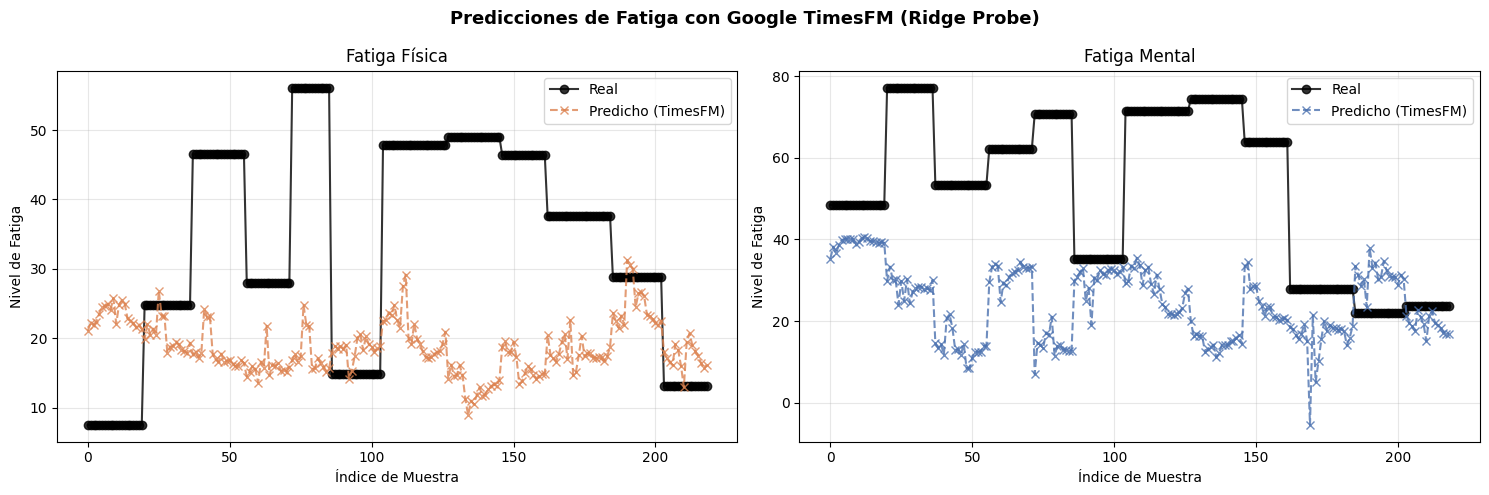

[OK] Gráfica guardada en: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\output\predicciones_timesfm.png


In [9]:
if TIMESFM_AVAILABLE and len(TIMESFM_RESULTS) > 0:
    # Tomar el último fold para graficar
    y_true_plot = y_val
    y_pred_plot = y_pred

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("Predicciones de Fatiga con Google TimesFM (Ridge Probe)", fontsize=13, fontweight='bold')

    # Fatiga Física
    ax = axes[0]
    ax.plot(y_true_plot[:, 0], label="Real", color="black", alpha=0.8, marker='o')
    ax.plot(y_pred_plot[:, 0], label="Predicho (TimesFM)", color="#dd8452", alpha=0.8, marker='x', linestyle='--')
    ax.set_title("Fatiga Física")
    ax.set_ylabel("Nivel de Fatiga")
    ax.set_xlabel("Índice de Muestra")
    ax.grid(alpha=0.3)
    ax.legend()

    # Fatiga Mental
    ax = axes[1]
    ax.plot(y_true_plot[:, 1], label="Real", color="black", alpha=0.8, marker='o')
    ax.plot(y_pred_plot[:, 1], label="Predicho (TimesFM)", color="#4c72b0", alpha=0.8, marker='x', linestyle='--')
    ax.set_title("Fatiga Mental")
    ax.set_ylabel("Nivel de Fatiga")
    ax.set_xlabel("Índice de Muestra")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    fig_path = output_dir / "predicciones_timesfm.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[OK] Gráfica guardada en: {fig_path}")